# Phase 4: Posterior Predictive Checks

This notebook performs posterior predictive checks (PPCs) using the fitted outputs from the earlier phases. It **does not refit** the Phase 1 mood model or the Phase 3 user-taste model. Instead, it loads the saved model artifacts and asks whether generated songs and generated listen events look like the real data.

The checks follow the Phase 4 project goal: compare fake-vs-real feature distributions, mood-frequency distributions, predicted listen probabilities, calibration, and listen-count distributions.

## 0  Imports and shared configuration

We use the same import style and random seed convention as the earlier notebooks. All saved artifacts are expected under the local `data/` directory of the project repository.

In [1]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pathlib import Path

np.random.seed(67)
torch.manual_seed(67)
pyro.set_rng_seed(67)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pyro 1.9.1, torch 2.11.0, numpy 2.2.6


## 1  Locate project data and load Phase 0 data

Phase 0 is still the source of truth for the raw cleaned tables: `songs_clean.csv` and `listens_clean.csv`. Phase 1 and Phase 3 save fitted model artifacts into subdirectories under `data/`, which this notebook uses for PPCs.

In [2]:
def find_project_root(start=None, project_name="MBML---2026"):
    start = Path.cwd() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        if p.name == project_name:
            return p
    fallback = Path.home() / "Desktop" / "mbml" / project_name
    if fallback.exists():
        return fallback
    return start

REPO_ROOT = find_project_root()
DATA_DIR = REPO_ROOT / 'data'

SONGS_CSV = DATA_DIR / 'songs_clean.csv'
LISTENS_CSV = DATA_DIR / 'listens_clean.csv'

assert SONGS_CSV.exists(), f"{SONGS_CSV} not found — run Phase 0 first."
assert LISTENS_CSV.exists(), f"{LISTENS_CSV} not found — run Phase 0 first."

df_songs_raw = pd.read_csv(SONGS_CSV)
df_listens_raw = pd.read_csv(LISTENS_CSV)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR :", DATA_DIR)
print(f"Songs loaded:   {len(df_songs_raw):,}")
print(f"Listens loaded: {len(df_listens_raw):,}")

REPO_ROOT: /Users/jacobbrams/Desktop/MBML---2026
DATA_DIR : /Users/jacobbrams/Desktop/MBML---2026/data
Songs loaded:   292,254
Listens loaded: 16,810,698


## 2  Load Phase 1 mood-model outputs

The Phase 1 save cell should have written posterior samples or at least posterior medians for the mood model. Phase 4 uses those parameters to generate synthetic songs from the fitted mixed-likelihood model.

In [3]:
PHASE1_OUT_DIR = DATA_DIR / 'phase1_processed'
assert PHASE1_OUT_DIR.exists(), (
    f"{PHASE1_OUT_DIR} not found. Run the Phase 1 save-contract cell first."
)

# Core arrays used for real-vs-fake comparisons.
X_cont_np = np.load(PHASE1_OUT_DIR / 'X_cont.npy')
X_key_np = np.load(PHASE1_OUT_DIR / 'X_key.npy')
X_ts_np = np.load(PHASE1_OUT_DIR / 'X_ts.npy')
X_mode_np = np.load(PHASE1_OUT_DIR / 'X_mode.npy')

# Metadata.
import json
with open(PHASE1_OUT_DIR / 'phase1_metadata.json', 'r') as f:
    phase1_meta = json.load(f)

CONT_COLS = phase1_meta['continuous_columns']
N_KEY = int(phase1_meta['N_KEY'])
N_TS = int(phase1_meta['N_TS'])
KEY_NAMES = phase1_meta.get('KEY_NAMES', [f'key={i}' for i in range(N_KEY)])
TS_LABELS = phase1_meta.get('TS_LABELS', [f'ts={i}' for i in range(N_TS)])
MOOD_NAMES = phase1_meta.get('MOOD_NAMES', [f'Mood {i}' for i in range(int(phase1_meta.get('K', 10)))])

# Posterior samples are preferred; posterior medians are a fallback.
posterior_samples_path = PHASE1_OUT_DIR / 'phase1_svi_posterior_samples.pt'
posterior_median_path = PHASE1_OUT_DIR / 'phase1_svi_median.pt'

if posterior_samples_path.exists():
    mood_posterior = torch.load(posterior_samples_path, map_location='cpu')
    print("Loaded Phase 1 SVI posterior samples.")
elif posterior_median_path.exists():
    median = torch.load(posterior_median_path, map_location='cpu')
    mood_posterior = {k: v.unsqueeze(0) for k, v in median.items()}
    print("Loaded Phase 1 SVI posterior median only; PPC will use point-parameter draws.")
else:
    raise FileNotFoundError(
        "Need either phase1_svi_posterior_samples.pt or phase1_svi_median.pt in data/phase1_processed."
    )

z_map = np.load(PHASE1_OUT_DIR / 'z_map.npy') if (PHASE1_OUT_DIR / 'z_map.npy').exists() else None

print("Phase 1 arrays:")
print("X_cont_np:", X_cont_np.shape)
print("X_key_np :", X_key_np.shape)
print("X_ts_np  :", X_ts_np.shape)
print("X_mode_np:", X_mode_np.shape)
print("Mood posterior sites:")
for k, v in mood_posterior.items():
    print(f"  {k:12s}: {tuple(v.shape)}")
if z_map is not None:
    print("z_map:", z_map.shape)

Loaded Phase 1 SVI posterior median only; PPC will use point-parameter draws.
Phase 1 arrays:
X_cont_np: (292254, 3)
X_key_np : (292254,)
X_ts_np  : (292254,)
X_mode_np: (292254,)
Mood posterior sites:
  pi          : (1, 10)
  mu_cont     : (1, 10, 3)
  sigma_cont  : (1, 10, 3)
  theta_key   : (1, 10, 12)
  theta_ts    : (1, 10, 6)
  p_mode      : (1, 10)
z_map: (292254,)


## 3  Load Phase 3 user-taste outputs

Phase 3 contains the fitted user-taste model. We load the posterior taste profiles, user activity bias, song popularity bias, and learned global calibration terms so that Phase 4 evaluates the **same likelihood** used in Phase 3.

In [4]:
PHASE3_OUT_DIR = DATA_DIR / 'phase3_processed'
assert PHASE3_OUT_DIR.exists(), (
    f"{PHASE3_OUT_DIR} not found. Run the Phase 3 save-contract cell first."
)

theta_post = np.load(PHASE3_OUT_DIR / 'theta_post.npy')
entropy = np.load(PHASE3_OUT_DIR / 'entropy.npy') if (PHASE3_OUT_DIR / 'entropy.npy').exists() else None

# These are essential for using the refined Phase 3 listen model.
alpha_u_post = np.load(PHASE3_OUT_DIR / 'alpha_u_post.npy')
gamma_s_post = np.load(PHASE3_OUT_DIR / 'gamma_s_post.npy')

df_listens = pd.read_csv(PHASE3_OUT_DIR / 'df_listens_phase3_used.csv')
df_users = pd.read_csv(PHASE3_OUT_DIR / 'users_phase3.csv')

with open(PHASE3_OUT_DIR / 'phase3_metadata.json', 'r') as f:
    phase3_meta = json.load(f)

K = int(phase3_meta['K'])
U = int(phase3_meta['U'])
BASE_LOGIT = float(phase3_meta['BASE_LOGIT'])
TASTE_SCALE = float(phase3_meta['TASTE_SCALE'])
MOOD_NAMES = phase3_meta.get('MOOD_NAMES', MOOD_NAMES)

required_cols = {'user_idx', 'song_idx', 'mood', 'listened'}
assert required_cols.issubset(df_listens.columns), (
    f"df_listens_phase3_used.csv must contain {required_cols}; found {df_listens.columns.tolist()}"
)

print("Loaded Phase 3 outputs:")
print("theta_post  :", theta_post.shape)
print("alpha_u_post:", alpha_u_post.shape)
print("gamma_s_post:", gamma_s_post.shape)
print("df_listens  :", df_listens.shape)
print(f"K={K}, U={U}, BASE_LOGIT={BASE_LOGIT:.3f}, TASTE_SCALE={TASTE_SCALE:.3f}")

Loaded Phase 3 outputs:
theta_post  : (988, 10)
alpha_u_post: (988,)
gamma_s_post: (292254,)
df_listens  : (16810698, 7)
K=10, U=988, BASE_LOGIT=-2.529, TASTE_SCALE=3.507


## 4  Posterior predictive song generator

For each posterior draw, we sample new mood assignments and then sample the observed audio variables from the fitted likelihoods. Continuous features are sampled from Normal distributions, key and time signature from Categorical distributions, and mode from a Bernoulli distribution.

In [5]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def get_param_draw(posterior, draw_idx):
    # Extract one posterior draw, cycling if fewer draws are available.
    out = {}
    for name, value in posterior.items():
        if not isinstance(value, torch.Tensor):
            value = torch.tensor(value)
        n_draws = value.shape[0]
        out[name] = value[draw_idx % n_draws]
    return out


def sample_synthetic_songs(param, n_songs, rng):
    pi = to_numpy(param['pi'])
    mu_cont = to_numpy(param['mu_cont'])
    sigma_cont = np.maximum(to_numpy(param['sigma_cont']), 1e-6)
    theta_key = to_numpy(param['theta_key'])
    theta_ts = to_numpy(param['theta_ts'])
    p_mode = np.clip(to_numpy(param['p_mode']), 1e-6, 1 - 1e-6)

    K_local = len(pi)
    pi = pi / pi.sum()

    z = rng.choice(K_local, size=n_songs, p=pi)

    x_cont = np.zeros((n_songs, mu_cont.shape[1]), dtype=np.float32)
    x_key = np.zeros(n_songs, dtype=int)
    x_ts = np.zeros(n_songs, dtype=int)
    x_mode = np.zeros(n_songs, dtype=int)

    for k in range(K_local):
        idx = np.where(z == k)[0]
        if len(idx) == 0:
            continue
        x_cont[idx] = rng.normal(mu_cont[k], sigma_cont[k], size=(len(idx), mu_cont.shape[1]))
        x_key[idx] = rng.choice(theta_key.shape[1], size=len(idx), p=theta_key[k] / theta_key[k].sum())
        x_ts[idx] = rng.choice(theta_ts.shape[1], size=len(idx), p=theta_ts[k] / theta_ts[k].sum())
        x_mode[idx] = rng.binomial(1, p_mode[k], size=len(idx))

    return z, x_cont, x_key, x_ts, x_mode


N_PPC = 100
N_FAKE_SONGS = 1000
rng = np.random.default_rng(67)

fake_mood_all = []
fake_cont_all = []
fake_key_all = []
fake_ts_all = []
fake_mode_all = []

for draw_idx in range(N_PPC):
    param = get_param_draw(mood_posterior, draw_idx)
    z_fake, cont_fake, key_fake, ts_fake, mode_fake = sample_synthetic_songs(param, N_FAKE_SONGS, rng)
    fake_mood_all.append(z_fake)
    fake_cont_all.append(cont_fake)
    fake_key_all.append(key_fake)
    fake_ts_all.append(ts_fake)
    fake_mode_all.append(mode_fake)

fake_mood_all = np.asarray(fake_mood_all)
fake_cont_all = np.asarray(fake_cont_all)
fake_key_all = np.asarray(fake_key_all)
fake_ts_all = np.asarray(fake_ts_all)
fake_mode_all = np.asarray(fake_mode_all)

print("Synthetic song arrays:")
print("fake_mood_all:", fake_mood_all.shape)
print("fake_cont_all:", fake_cont_all.shape)
print("fake_key_all :", fake_key_all.shape)
print("fake_ts_all  :", fake_ts_all.shape)
print("fake_mode_all:", fake_mode_all.shape)

Synthetic song arrays:
fake_mood_all: (100, 1000)
fake_cont_all: (100, 1000, 3)
fake_key_all : (100, 1000)
fake_ts_all  : (100, 1000)
fake_mode_all: (100, 1000)


## 5  PPC for continuous audio features

We compare the observed z-scored continuous features to synthetic features generated from the fitted mood model. Good posterior predictive fit means the fake and real histograms should broadly overlap.

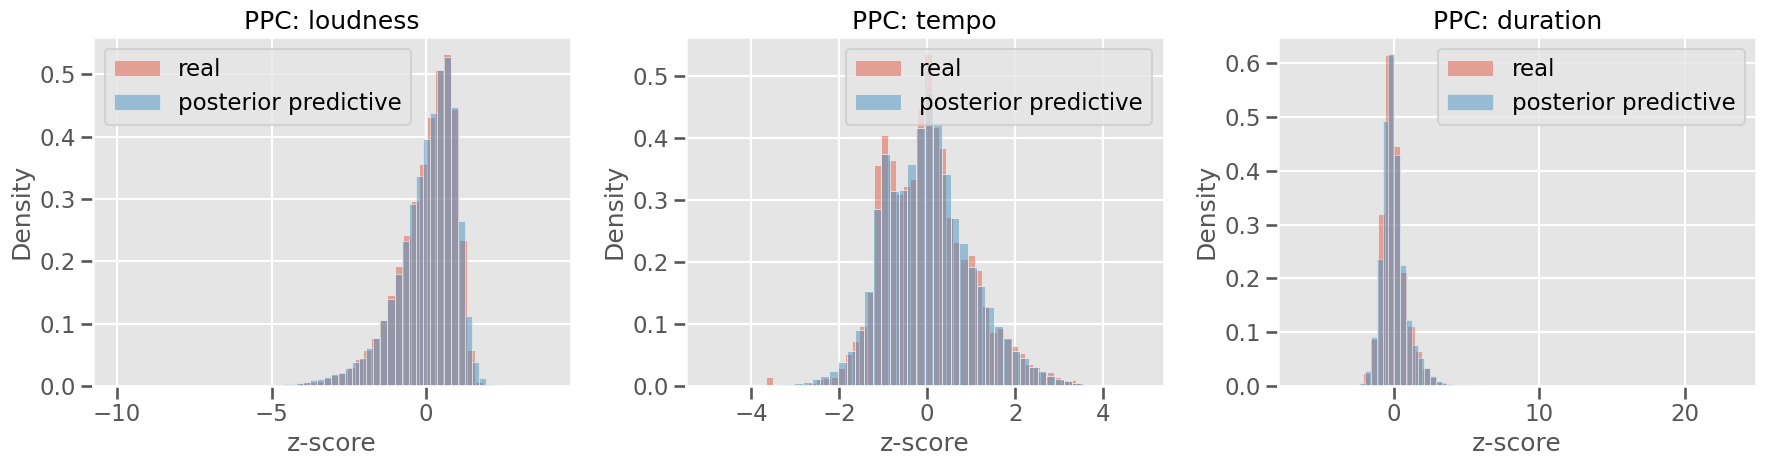

,feature,real_mean,fake_mean,mean_abs_diff,real_std,fake_std,std_abs_diff
0,loudness,-0.0,0.0035,0.0035,1.0,1.0006,0.0006
1,tempo,0.0,0.0049,0.0049,1.0,1.0029,0.0029
2,duration,-0.0,-0.0030,0.0030,1.0,1.0048,0.0048


In [6]:
fake_cont_flat = fake_cont_all.reshape(-1, fake_cont_all.shape[-1])

fig, axes = plt.subplots(1, len(CONT_COLS), figsize=(18, 5))
if len(CONT_COLS) == 1:
    axes = [axes]

for d, (ax, col) in enumerate(zip(axes, CONT_COLS)):
    sns.histplot(X_cont_np[:, d], bins=50, stat='density', alpha=0.45, label='real', ax=ax)
    sns.histplot(fake_cont_flat[:, d], bins=50, stat='density', alpha=0.45, label='posterior predictive', ax=ax)
    ax.set_title(f'PPC: {col}')
    ax.set_xlabel('z-score')
    ax.legend()

plt.tight_layout()
plt.show()

feature_mean_real = X_cont_np.mean(axis=0)
feature_mean_fake = fake_cont_flat.mean(axis=0)
feature_std_real = X_cont_np.std(axis=0)
feature_std_fake = fake_cont_flat.std(axis=0)

feature_summary = pd.DataFrame({
    'feature': CONT_COLS,
    'real_mean': feature_mean_real,
    'fake_mean': feature_mean_fake,
    'mean_abs_diff': np.abs(feature_mean_real - feature_mean_fake),
    'real_std': feature_std_real,
    'fake_std': feature_std_fake,
    'std_abs_diff': np.abs(feature_std_real - feature_std_fake),
})

feature_summary.round(4)

## 6  PPC for categorical audio features

Key, time signature, and mode are discrete variables. We compare their observed empirical proportions to posterior predictive proportions and show 90% predictive intervals across posterior draws.

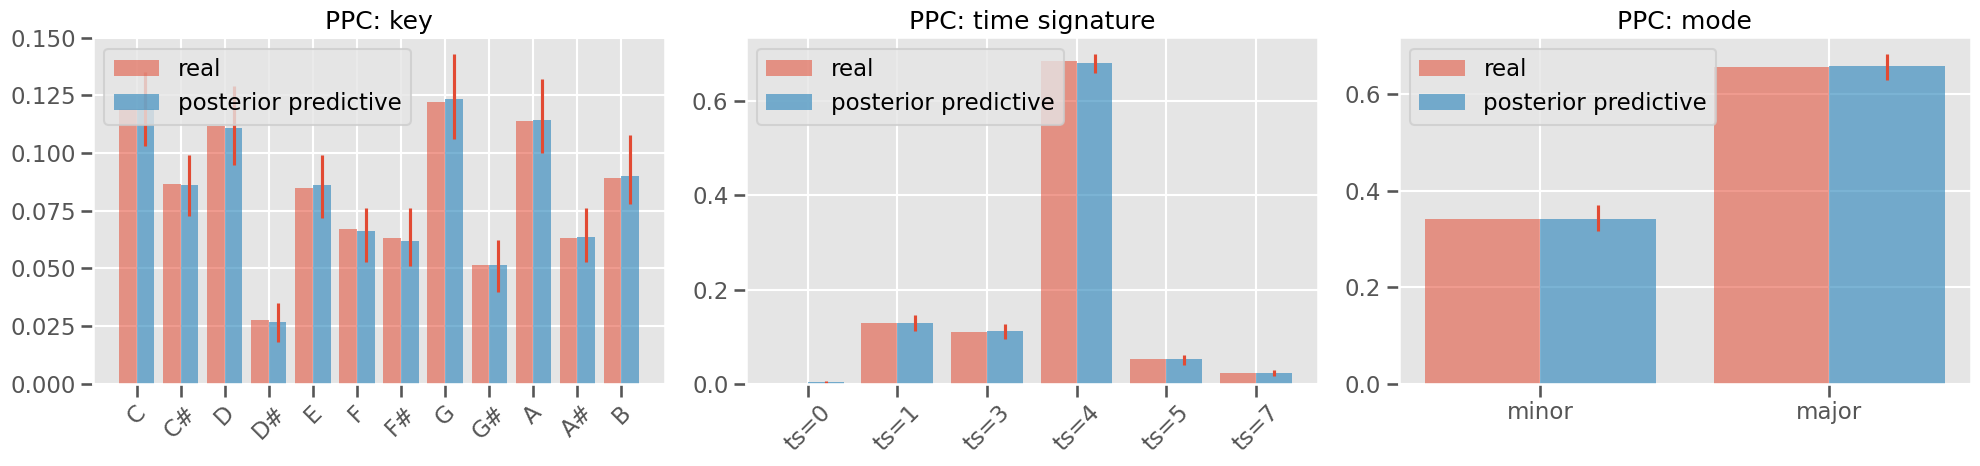

In [7]:
def posterior_predictive_category_summary(fake_arr, n_categories):
    fake_arr = np.asarray(fake_arr)
    if fake_arr.ndim == 1:
        fake_arr = fake_arr[None, :]
    props = []
    for sample in fake_arr:
        sample = np.asarray(sample).astype(int).ravel()
        counts = np.bincount(sample, minlength=n_categories)[:n_categories]
        props.append(counts / max(len(sample), 1))
    props = np.stack(props)
    return props.mean(0), np.percentile(props, 5, axis=0), np.percentile(props, 95, axis=0)

key_mean, key_lo, key_hi = posterior_predictive_category_summary(fake_key_all, N_KEY)
ts_mean, ts_lo, ts_hi = posterior_predictive_category_summary(fake_ts_all, N_TS)
mode_mean, mode_lo, mode_hi = posterior_predictive_category_summary(fake_mode_all, 2)

real_key = np.bincount(X_key_np.astype(int), minlength=N_KEY)[:N_KEY] / len(X_key_np)
real_ts = np.bincount(X_ts_np.astype(int), minlength=N_TS)[:N_TS] / len(X_ts_np)
real_mode = np.bincount(X_mode_np.astype(int), minlength=2)[:2] / len(X_mode_np)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

x = np.arange(N_KEY)
axes[0].bar(x - 0.2, real_key, width=0.4, label='real', alpha=0.55)
axes[0].bar(x + 0.2, key_mean, width=0.4, label='posterior predictive', alpha=0.65)
axes[0].errorbar(x + 0.2, key_mean, yerr=[key_mean - key_lo, key_hi - key_mean], fmt='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels(KEY_NAMES, rotation=45)
axes[0].set_title('PPC: key')
axes[0].legend()

x = np.arange(N_TS)
axes[1].bar(x - 0.2, real_ts, width=0.4, label='real', alpha=0.55)
axes[1].bar(x + 0.2, ts_mean, width=0.4, label='posterior predictive', alpha=0.65)
axes[1].errorbar(x + 0.2, ts_mean, yerr=[ts_mean - ts_lo, ts_hi - ts_mean], fmt='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels(TS_LABELS, rotation=45)
axes[1].set_title('PPC: time signature')
axes[1].legend()

x = np.arange(2)
axes[2].bar(x - 0.2, real_mode, width=0.4, label='real', alpha=0.55)
axes[2].bar(x + 0.2, mode_mean, width=0.4, label='posterior predictive', alpha=0.65)
axes[2].errorbar(x + 0.2, mode_mean, yerr=[mode_mean - mode_lo, mode_hi - mode_mean], fmt='none')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['minor', 'major'])
axes[2].set_title('PPC: mode')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7  PPC for mood-frequency distribution

The fitted model should generate mood frequencies similar to the real MAP mood assignments from Phase 1. This is a direct check of the learned mixture weights $\pi$.

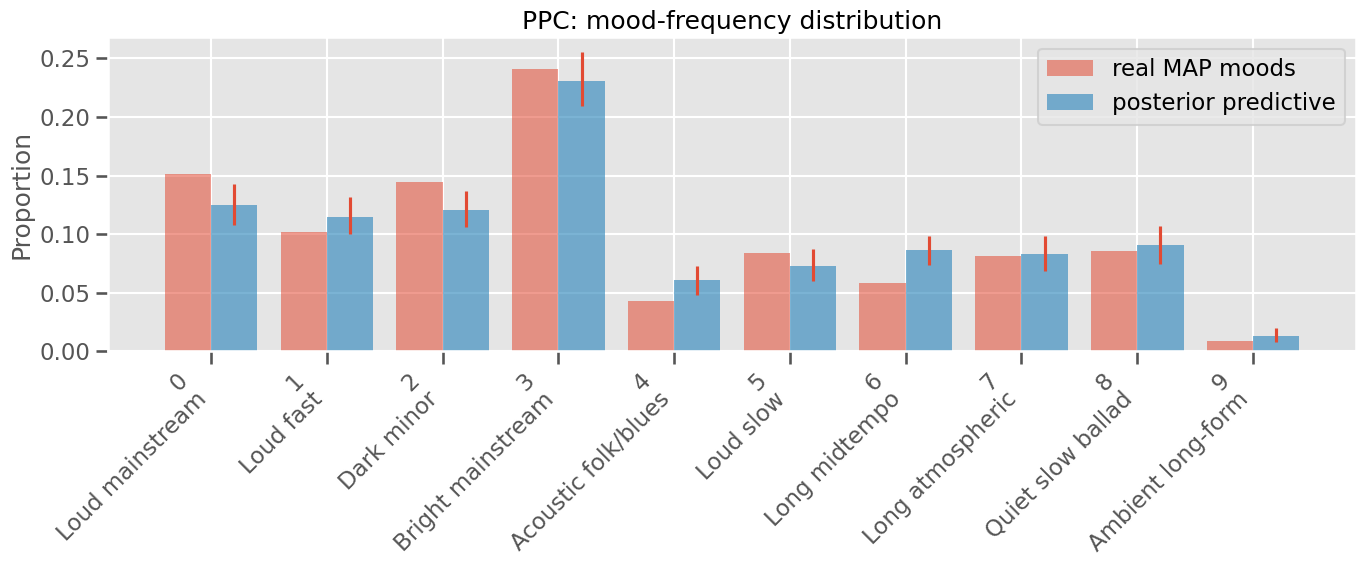

Mood-frequency L1 distance: 0.142


In [8]:
mood_mean, mood_lo, mood_hi = posterior_predictive_category_summary(fake_mood_all, K)

if z_map is not None:
    real_mood = np.bincount(z_map.astype(int), minlength=K)[:K] / len(z_map)
else:
    # Fallback: use the mean posterior mixture weights if no MAP z was saved.
    pi_arr = to_numpy(mood_posterior['pi'])
    real_mood = pi_arr.mean(axis=0)
    real_mood = real_mood / real_mood.sum()

x = np.arange(K)
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, real_mood, width=0.4, label='real MAP moods', alpha=0.55)
plt.bar(x + 0.2, mood_mean, width=0.4, label='posterior predictive', alpha=0.65)
plt.errorbar(x + 0.2, mood_mean, yerr=[mood_mean - mood_lo, mood_hi - mood_mean], fmt='none')
plt.xticks(x, [f'{k}\n{MOOD_NAMES[k] if k < len(MOOD_NAMES) else f"Mood {k}"}' for k in range(K)], rotation=45, ha='right')
plt.ylabel('Proportion')
plt.title('PPC: mood-frequency distribution')
plt.legend()
plt.tight_layout()
plt.show()

mood_l1 = float(np.abs(real_mood - mood_mean).sum())
print(f"Mood-frequency L1 distance: {mood_l1:.3f}")

## 8  Listen probability calibration using Phase 3 likelihood

This is the key Phase 4 check for the user-taste extension. We compute predicted listen probabilities using the same learned Phase 3 formula:

$$\mathrm{logit}(p_{us}) = b + \beta,	heta_{u,z_s} + \alpha_u + \gamma_s.$$

Then we compare predicted probabilities to observed listen frequencies in calibration bins.

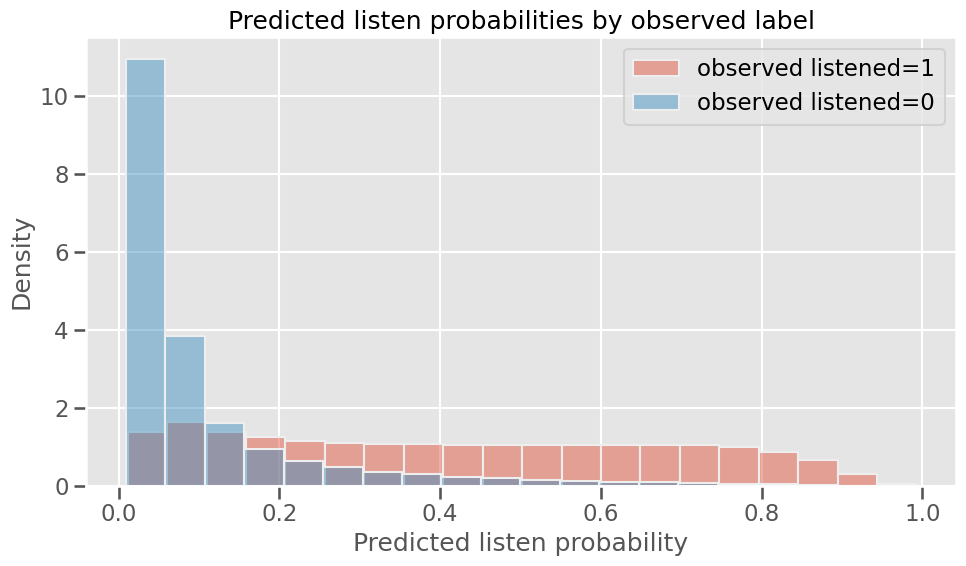

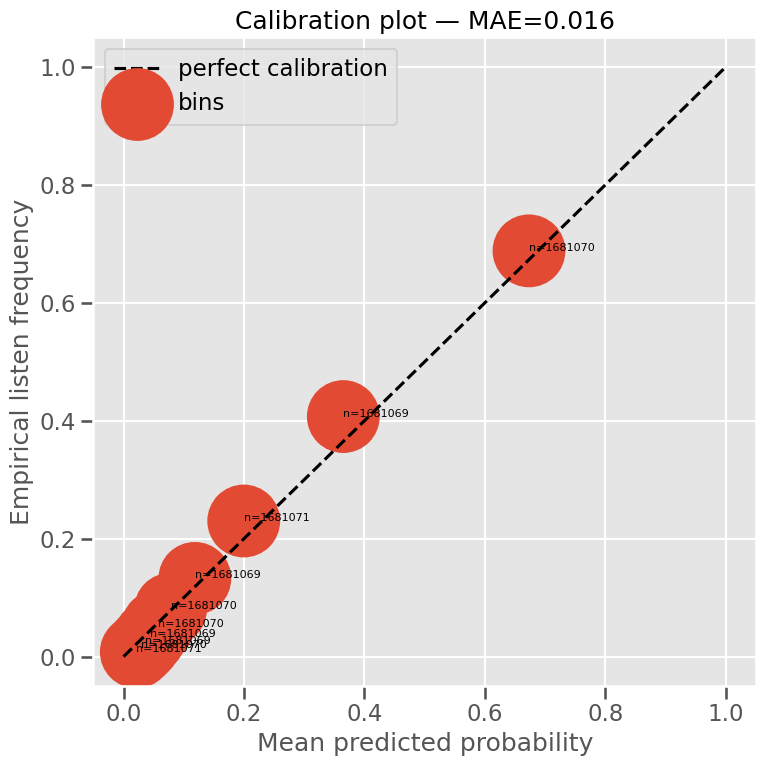

 pred_mean  empirical_rate       n  abs_error
    0.0212          0.0079 1681071     0.0133
    0.0284          0.0147 1681070     0.0137
    0.0351          0.0220 1681069     0.0131
    0.0439          0.0333 1681069     0.0106
    0.0567          0.0510 1681070     0.0057
    0.0780          0.0803 1681070     0.0023
    0.1184          0.1326 1681069     0.0142
    0.1995          0.2299 1681071     0.0303
    0.3649          0.4070 1681069     0.0421
    0.6731          0.6880 1681070     0.0148

Calibration MAE: 0.0160


In [ ]:
user_idx_t = torch.tensor(df_listens['user_idx'].values, dtype=torch.long)
song_idx_t = torch.tensor(df_listens['song_idx'].values, dtype=torch.long)
mood_idx_t = torch.tensor(df_listens['mood'].values, dtype=torch.long)
listened_t = torch.tensor(df_listens['listened'].values, dtype=torch.float32)

theta_t = torch.tensor(theta_post, dtype=torch.float32)
alpha_u_t = torch.tensor(alpha_u_post, dtype=torch.float32)
gamma_s_t = torch.tensor(gamma_s_post, dtype=torch.float32)

# Safety check: song_idx must index gamma_s.
max_song_idx = int(song_idx_t.max())
assert max_song_idx < len(gamma_s_t), (
    f"song_idx max is {max_song_idx}, but gamma_s_post length is {len(gamma_s_t)}. "
    "Phase 3 must save gamma_s aligned to df_listens['song_idx']."
)

with torch.no_grad():
    theta_selected = theta_t[user_idx_t, mood_idx_t]
    logits = BASE_LOGIT + TASTE_SCALE * theta_selected + alpha_u_t[user_idx_t] + gamma_s_t[song_idx_t]
    pred_prob = torch.sigmoid(logits).cpu().numpy()

obs_listen = listened_t.cpu().numpy()

plt.figure(figsize=(10, 6))
sns.histplot(pred_prob[obs_listen == 1], bins=40, stat='density', alpha=0.45, label='observed listened=1')
sns.histplot(pred_prob[obs_listen == 0], bins=40, stat='density', alpha=0.45, label='observed listened=0')
plt.xlabel('Predicted listen probability')
plt.title('Predicted listen probabilities by observed label')
plt.legend()
plt.tight_layout()
plt.show()

calib_df = pd.DataFrame({'pred_prob': pred_prob, 'observed': obs_listen})
calib_df['bin'] = pd.qcut(calib_df['pred_prob'], q=10, duplicates='drop')
calib = calib_df.groupby('bin', observed=True).agg(
    pred_mean=('pred_prob', 'mean'),
    empirical_rate=('observed', 'mean'),
    n=('observed', 'size'),
).reset_index()
calib['abs_error'] = (calib['pred_mean'] - calib['empirical_rate']).abs()
calib_mae = float(calib['abs_error'].mean())

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
plt.scatter(calib['pred_mean'], calib['empirical_rate'], s=np.sqrt(calib['n']) * 2, label='bins')
for _, row in calib.iterrows():
    plt.text(row['pred_mean'], row['empirical_rate'], f"n={int(row['n'])}", fontsize=8)
plt.xlabel('Mean predicted probability')
plt.ylabel('Empirical listen frequency')
plt.title(f'Calibration plot — MAE={calib_mae:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print(calib[['pred_mean', 'empirical_rate', 'n', 'abs_error']].round(4).to_string(index=False))
print(f"\nCalibration MAE: {calib_mae:.4f}")

## 9  Listen-count posterior predictive check

Using the Phase 3 predicted probabilities, we simulate new listen outcomes for the same observed $(u,s)$ pairs. We then compare the distribution of positive listen counts per user between real and fake data.

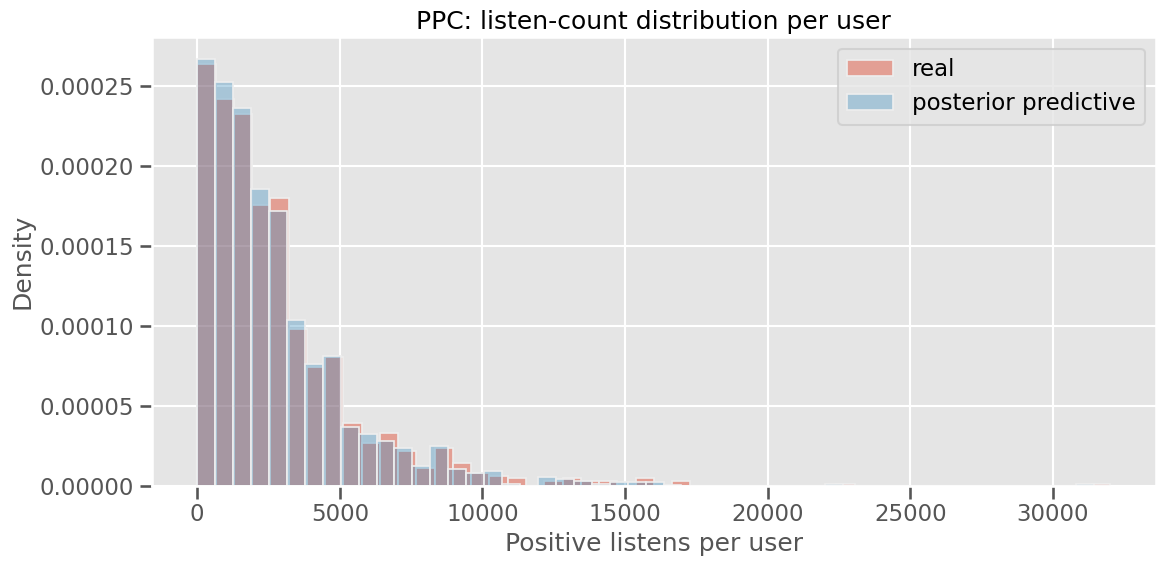

Real listen counts: median=2071.0, mean=2835.8
Fake listen counts: median=2012.0, mean=2755.3


In [10]:
N_LISTEN_PPC = 100
rng = np.random.default_rng(67)

real_counts = df_listens.groupby('user_idx')['listened'].sum().reindex(range(U), fill_value=0).values
fake_counts_all = []

for _ in range(N_LISTEN_PPC):
    fake_l = rng.binomial(1, pred_prob).astype(int)
    fake_df = pd.DataFrame({'user_idx': df_listens['user_idx'].values, 'fake_l': fake_l})
    fake_counts = fake_df.groupby('user_idx')['fake_l'].sum().reindex(range(U), fill_value=0).values
    fake_counts_all.append(fake_counts)

fake_counts_all = np.stack(fake_counts_all)
fake_counts_flat = fake_counts_all.reshape(-1)

plt.figure(figsize=(12, 6))
sns.histplot(real_counts, bins=50, stat='density', alpha=0.45, label='real')
sns.histplot(fake_counts_flat, bins=50, stat='density', alpha=0.35, label='posterior predictive')
plt.xlabel('Positive listens per user')
plt.title('PPC: listen-count distribution per user')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Real listen counts: median={np.median(real_counts):.1f}, mean={np.mean(real_counts):.1f}")
print(f"Fake listen counts: median={np.median(fake_counts_flat):.1f}, mean={np.mean(fake_counts_flat):.1f}")

## 10  Synthetic recovery sanity check

This synthetic experiment checks whether the Phase 1 model and SVI pipeline can recover known parameters when data are generated from the same model family. A small artificial song corpus is drawn from the prior, the model is refit with the same SVI machinery, and estimated components are aligned to the true components using Hungarian matching to account for label switching. This is not a real-data PPC; it is a controlled implementation sanity check that supports the claim that the inference code can recover the intended latent structure under ideal conditions.

/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/jacobbrams/Desktop/MBML---2026/.venv/lib/python3.10/site-packages/sklearn/cluster/_k

synthetic SVI step=   0 loss=32,913
synthetic SVI step= 300 loss=30,595
synthetic SVI step= 600 loss=30,539
synthetic SVI step= 900 loss=30,534
synthetic SVI step=1200 loss=30,506


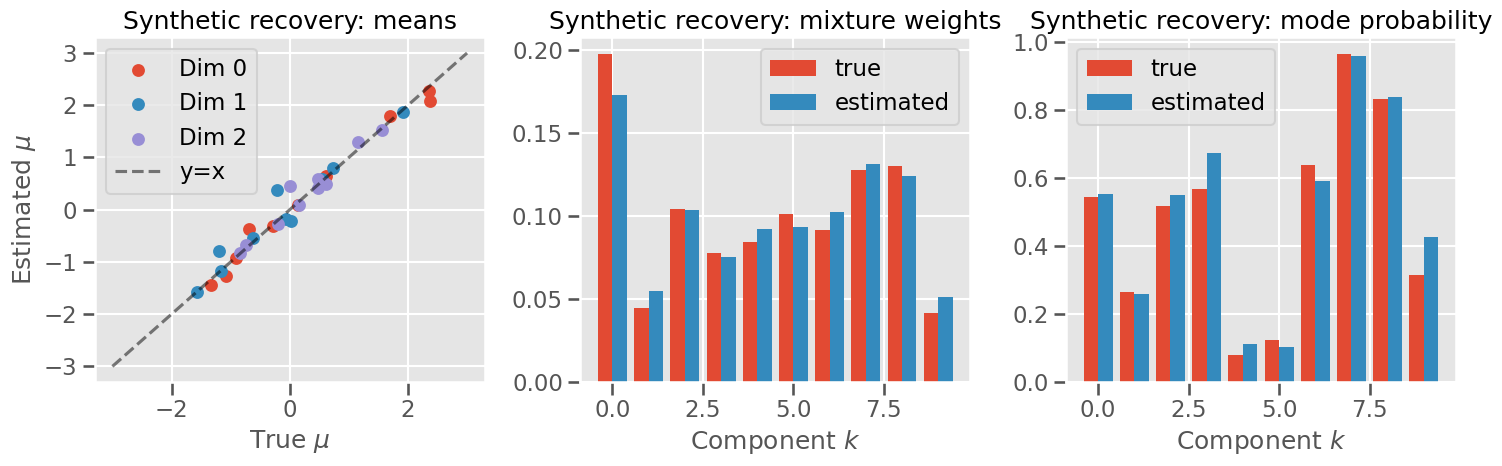

Synthetic recovery metrics:
  mu MAE:     0.1338
  pi TVD:     0.0413
  p_mode MAE: 0.0377

Synthetic recovery acceptable.


In [11]:
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam
from pyro.ops.indexing import Vindex
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

# Synthetic recovery settings. These are deliberately smaller than the real corpus.
K_SYN = int(K)
D_SYN = int(len(CONT_COLS))
N_KEY_SYN = int(N_KEY)
N_TS_SYN = int(N_TS)
N_SYN_SONGS = 3000
N_SYN_STEPS = 1500

pyro.set_rng_seed(67)
torch.manual_seed(67)
np.random.seed(67)

# 1. Sample ground-truth parameters from the same prior family as Phase 1.
pi_true = dist.Dirichlet(5.0 * torch.ones(K_SYN)).sample()
mu_true = dist.Normal(torch.zeros(K_SYN, D_SYN), torch.ones(K_SYN, D_SYN)).sample()
sigma_true = dist.LogNormal(torch.zeros(K_SYN, D_SYN), 0.5 * torch.ones(K_SYN, D_SYN)).sample()
theta_key_true = dist.Dirichlet(torch.ones(N_KEY_SYN)).sample((K_SYN,))
theta_ts_true = dist.Dirichlet(torch.ones(N_TS_SYN)).sample((K_SYN,))
p_mode_true = dist.Beta(2.0 * torch.ones(K_SYN), 2.0 * torch.ones(K_SYN)).sample()

# 2. Generate a synthetic corpus from the known parameters.
z_syn = dist.Categorical(pi_true).sample((N_SYN_SONGS,))
x_cont_syn = dist.Normal(mu_true[z_syn], sigma_true[z_syn]).sample()
x_key_syn = dist.Categorical(theta_key_true[z_syn]).sample()
x_ts_syn = dist.Categorical(theta_ts_true[z_syn]).sample()
x_mode_syn = dist.Bernoulli(p_mode_true[z_syn]).sample()


@config_enumerate(default="parallel")
def synthetic_model(x_cont, x_key, x_ts, x_mode, K_local):
    D_local = x_cont.shape[1]

    pi = pyro.sample(
        "pi",
        dist.Dirichlet(5.0 * torch.ones(K_local))
    )

    with pyro.plate("moods", K_local):
        mu_cont = pyro.sample(
            "mu_cont",
            dist.Normal(torch.zeros(D_local), torch.ones(D_local)).to_event(1)
        )
        sigma_cont = pyro.sample(
            "sigma_cont",
            dist.LogNormal(torch.zeros(D_local), 0.5 * torch.ones(D_local)).to_event(1)
        )
        theta_key = pyro.sample(
            "theta_key",
            dist.Dirichlet(torch.ones(N_KEY_SYN))
        )
        theta_ts = pyro.sample(
            "theta_ts",
            dist.Dirichlet(torch.ones(N_TS_SYN))
        )
        p_mode = pyro.sample(
            "p_mode",
            dist.Beta(2.0, 2.0)
        )

    with pyro.plate("songs", x_cont.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi))

        mu_z = Vindex(mu_cont)[z]
        sigma_z = Vindex(sigma_cont)[z]
        theta_key_z = Vindex(theta_key)[z]
        theta_ts_z = Vindex(theta_ts)[z]
        p_mode_z = Vindex(p_mode)[z]

        pyro.sample(
            "obs_cont",
            dist.Normal(mu_z, sigma_z).to_event(1),
            obs=x_cont
        )
        pyro.sample(
            "obs_key",
            dist.Categorical(theta_key_z),
            obs=x_key
        )
        pyro.sample(
            "obs_ts",
            dist.Categorical(theta_ts_z),
            obs=x_ts
        )
        pyro.sample(
            "obs_mode",
            dist.Bernoulli(p_mode_z),
            obs=x_mode
        )


# 3. Refit the model to the synthetic corpus using the same SVI structure.
pyro.clear_param_store()

km_syn = KMeans(n_clusters=K_SYN, n_init=10, random_state=67).fit(x_cont_syn.numpy())
centers_syn = torch.tensor(km_syn.cluster_centers_, dtype=torch.float32)

init_vals_syn = {
    "mu_cont": centers_syn,
    "pi": torch.ones(K_SYN) / K_SYN,
    "sigma_cont": torch.ones(K_SYN, D_SYN),
    "p_mode": 0.5 * torch.ones(K_SYN),
    "theta_key": torch.ones(K_SYN, N_KEY_SYN) / N_KEY_SYN,
    "theta_ts": torch.ones(K_SYN, N_TS_SYN) / N_TS_SYN,
}

guide_syn = AutoDiagonalNormal(
    pyro.poutine.block(synthetic_model, hide=["z"]),
    init_loc_fn=init_to_value(values=init_vals_syn),
    init_scale=0.05,
)

svi_syn = SVI(
    synthetic_model,
    guide_syn,
    Adam({"lr": 1e-2}),
    TraceEnum_ELBO(max_plate_nesting=2),
)

losses_syn = []
for step in range(N_SYN_STEPS):
    loss = svi_syn.step(x_cont_syn, x_key_syn, x_ts_syn, x_mode_syn, K_SYN)
    losses_syn.append(loss)
    if step % 300 == 0:
        print(f"synthetic SVI step={step:4d} loss={loss:,.0f}", flush=True)

post_median_syn = guide_syn.median()
mu_hat_raw = post_median_syn["mu_cont"].detach()
pi_hat_raw = post_median_syn["pi"].detach()
p_mode_hat_raw = post_median_syn["p_mode"].detach()

# 4. Align estimated components to the true components to handle label switching.
cost_matrix = torch.cdist(mu_true, mu_hat_raw, p=2).numpy()
row_ind, col_ind = linear_sum_assignment(cost_matrix)

row_t = torch.tensor(row_ind, dtype=torch.long)
col_t = torch.tensor(col_ind, dtype=torch.long)

mu_hat = torch.empty_like(mu_true)
pi_hat = torch.empty_like(pi_true)
p_mode_hat = torch.empty_like(p_mode_true)

mu_hat[row_t] = mu_hat_raw[col_t]
pi_hat[row_t] = pi_hat_raw[col_t]
p_mode_hat[row_t] = p_mode_hat_raw[col_t]

# 5. Recovery metrics.
mu_mae = torch.abs(mu_true - mu_hat).mean().item()
pi_tvd = 0.5 * torch.abs(pi_true - pi_hat).sum().item()
pmode_mae = torch.abs(p_mode_true - p_mode_hat).mean().item()

synthetic_recovery_metrics = {
    "n_synthetic_songs": int(N_SYN_SONGS),
    "n_svi_steps": int(N_SYN_STEPS),
    "mu_mae": float(mu_mae),
    "pi_tvd": float(pi_tvd),
    "p_mode_mae": float(pmode_mae),
    "final_elbo_loss": float(losses_syn[-1]),
    "mu_gate_pass": bool(mu_mae < 0.3),
    "pi_gate_pass": bool(pi_tvd < 0.05),
    "p_mode_gate_pass": bool(pmode_mae < 0.1),
}
synthetic_recovery_metrics["all_gates_pass"] = bool(
    synthetic_recovery_metrics["mu_gate_pass"]
    and synthetic_recovery_metrics["pi_gate_pass"]
    and synthetic_recovery_metrics["p_mode_gate_pass"]
)

# 6. Plot recovery.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for d in range(D_SYN):
    axes[0].scatter(mu_true[:, d].numpy(), mu_hat[:, d].numpy(), label=f"Dim {d}", s=60)
axes[0].plot([-3, 3], [-3, 3], "k--", alpha=0.5, label="y=x")
axes[0].set_title("Synthetic recovery: means")
axes[0].set_xlabel("True $\\mu$")
axes[0].set_ylabel("Estimated $\\mu$")
axes[0].legend()

x_idx = np.arange(K_SYN)
axes[1].bar(x_idx - 0.2, pi_true.numpy(), width=0.4, label="true")
axes[1].bar(x_idx + 0.2, pi_hat.numpy(), width=0.4, label="estimated")
axes[1].set_title("Synthetic recovery: mixture weights")
axes[1].set_xlabel("Component $k$")
axes[1].legend()

axes[2].bar(x_idx - 0.2, p_mode_true.numpy(), width=0.4, label="true")
axes[2].bar(x_idx + 0.2, p_mode_hat.numpy(), width=0.4, label="estimated")
axes[2].set_title("Synthetic recovery: mode probability")
axes[2].set_xlabel("Component $k$")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Synthetic recovery metrics:")
print(f"  mu MAE:     {mu_mae:.4f}")
print(f"  pi TVD:     {pi_tvd:.4f}")
print(f"  p_mode MAE: {pmode_mae:.4f}")

if synthetic_recovery_metrics["all_gates_pass"]:
    print("\nSynthetic recovery acceptable.")
else:
    print("\nSynthetic recovery warning: one or more metrics exceed the selected thresholds.")


## 11  Save Phase 4 outputs

We save numeric summaries and calibration bins so they can be used directly in the final report. The plots are diagnostic; the CSV files are the reproducible outputs.

In [12]:
PHASE4_OUT_DIR = DATA_DIR / 'phase4_processed'
PHASE4_OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_rows = []
for d, col in enumerate(CONT_COLS):
    summary_rows.append({
        'check': 'continuous_feature',
        'name': col,
        'real_mean': float(feature_mean_real[d]),
        'fake_mean': float(feature_mean_fake[d]),
        'mean_abs_diff': float(abs(feature_mean_real[d] - feature_mean_fake[d])),
        'real_std': float(feature_std_real[d]),
        'fake_std': float(feature_std_fake[d]),
        'std_abs_diff': float(abs(feature_std_real[d] - feature_std_fake[d])),
    })

summary_rows.append({'check': 'mood_frequency', 'name': 'L1', 'value': float(mood_l1)})
summary_rows.append({'check': 'listen_calibration', 'name': 'MAE', 'value': float(calib_mae)})

if 'synthetic_recovery_metrics' in globals():
    summary_rows.extend([
        {'check': 'synthetic_recovery', 'name': 'mu_mae', 'value': float(synthetic_recovery_metrics['mu_mae'])},
        {'check': 'synthetic_recovery', 'name': 'pi_tvd', 'value': float(synthetic_recovery_metrics['pi_tvd'])},
        {'check': 'synthetic_recovery', 'name': 'p_mode_mae', 'value': float(synthetic_recovery_metrics['p_mode_mae'])},
        {'check': 'synthetic_recovery', 'name': 'all_gates_pass', 'value': int(synthetic_recovery_metrics['all_gates_pass'])},
    ])

df_ppc_summary = pd.DataFrame(summary_rows)
df_ppc_summary.to_csv(PHASE4_OUT_DIR / 'phase4_ppc_summary.csv', index=False)
calib.to_csv(PHASE4_OUT_DIR / 'phase4_calibration_bins.csv', index=False)
feature_summary.to_csv(PHASE4_OUT_DIR / 'phase4_feature_summary.csv', index=False)

if 'synthetic_recovery_metrics' in globals():
    pd.DataFrame([synthetic_recovery_metrics]).to_csv(
        PHASE4_OUT_DIR / 'phase4_synthetic_recovery_metrics.csv',
        index=False,
    )
    np.save(PHASE4_OUT_DIR / 'synthetic_recovery_losses.npy', np.asarray(losses_syn))

np.save(PHASE4_OUT_DIR / 'real_mood_proportions.npy', real_mood)
np.save(PHASE4_OUT_DIR / 'fake_mood_proportions_mean.npy', mood_mean)
np.save(PHASE4_OUT_DIR / 'fake_mood_proportions_lo.npy', mood_lo)
np.save(PHASE4_OUT_DIR / 'fake_mood_proportions_hi.npy', mood_hi)
np.save(PHASE4_OUT_DIR / 'real_user_listen_counts.npy', real_counts)
np.save(PHASE4_OUT_DIR / 'fake_user_listen_counts.npy', fake_counts_all)

print("Saved Phase 4 outputs to:")
print(PHASE4_OUT_DIR)
for p in sorted(PHASE4_OUT_DIR.iterdir()):
    print('-', p.name)


Saved Phase 4 outputs to:
/Users/jacobbrams/Desktop/MBML---2026/data/phase4_processed
- X_cont_np.npy
- X_key_np.npy
- X_mode_np.npy
- X_ts_np.npy
- fake_cont_all.npy
- fake_key_all.npy
- fake_mode_all.npy
- fake_mood_all.npy
- fake_mood_proportions_hi.npy
- fake_mood_proportions_lo.npy
- fake_mood_proportions_mean.npy
- fake_ts_all.npy
- fake_user_listen_counts.npy
- figures
- obs_listen.npy
- phase4_calibration_bins.csv
- phase4_feature_summary.csv
- phase4_gate_summary.json
- phase4_ppc_summary.csv
- phase4_synthetic_recovery_metrics.csv
- phase4_synthetic_recovery_metrics.json
- phase4_synthetic_recovery_metrics_full.json
- pred_prob.npy
- real_mood_proportions.npy
- real_user_listen_counts.npy
- synthetic_recovery_losses.npy
- z_map.npy


## 12  Phase 4 gate summary

The gate is qualitative: real and fake feature histograms should overlap, mood frequencies should be close, and calibration should not show severe systematic bias. The summary below gives the key numerical checks to cite in the report.

In [13]:
print("=" * 70)
print("PHASE 4 GATE SUMMARY — posterior predictive checks")
print("=" * 70)
print(f"Posterior predictive samples: {N_PPC}")
print(f"Synthetic songs per sample:   {N_FAKE_SONGS:,}")
print(f"Listen PPC replicates:        {N_LISTEN_PPC}")
print()
for _, row in feature_summary.iterrows():
    print(
        f"{row['feature']:<10s} "
        f"mean diff={row['mean_abs_diff']:.3f}  "
        f"std diff={row['std_abs_diff']:.3f}"
    )
print()
print(f"Mood-frequency L1 distance:   {mood_l1:.3f}")
print(f"Calibration MAE:              {calib_mae:.3f}")

if 'synthetic_recovery_metrics' in globals():
    print()
    print("Synthetic recovery sanity check:")
    print(f"  synthetic songs: {synthetic_recovery_metrics['n_synthetic_songs']:,}")
    print(f"  SVI steps:       {synthetic_recovery_metrics['n_svi_steps']:,}")
    print(f"  mu MAE:          {synthetic_recovery_metrics['mu_mae']:.3f}")
    print(f"  pi TVD:          {synthetic_recovery_metrics['pi_tvd']:.3f}")
    print(f"  p_mode MAE:      {synthetic_recovery_metrics['p_mode_mae']:.3f}")
    print(f"  gates pass:      {synthetic_recovery_metrics['all_gates_pass']}")

print()
print("Interpretation:")
print("- Good PPC: real and fake histograms overlap, mood frequencies are close, calibration points are near diagonal.")
print("- Weak PPC: systematic shifts in feature histograms, missing rare categories, or calibration far from diagonal.")
print("- Synthetic recovery checks whether the implemented model can recover known parameters under ideal simulated data.")


PHASE 4 GATE SUMMARY — posterior predictive checks
Posterior predictive samples: 100
Synthetic songs per sample:   1,000
Listen PPC replicates:        100

loudness   mean diff=0.003  std diff=0.001
tempo      mean diff=0.005  std diff=0.003
duration   mean diff=0.003  std diff=0.005

Mood-frequency L1 distance:   0.142
Calibration MAE:              0.016

Synthetic recovery sanity check:
  synthetic songs: 3,000
  SVI steps:       1,500
  mu MAE:          0.134
  pi TVD:          0.041
  p_mode MAE:      0.038
  gates pass:      True

Interpretation:
- Good PPC: real and fake histograms overlap, mood frequencies are close, calibration points are near diagonal.
- Weak PPC: systematic shifts in feature histograms, missing rare categories, or calibration far from diagonal.
- Synthetic recovery checks whether the implemented model can recover known parameters under ideal simulated data.


## 13  Phase 4 conclusions

Phase 4 evaluates the fitted Phase 1 (mood) and Phase 3 (user-taste) models along three complementary axes: (i) posterior predictive checks on the observed audio features, (ii) calibration and posterior predictive checks on listen events, and (iii) a synthetic parameter-recovery sanity check on the Phase 1 inference pipeline.

### Audio-feature posterior predictive checks

Synthetic songs generated from $N_{\text{PPC}} = 100$ draws of the Phase 1 posterior reproduce the observed corpus on every measured statistic. For the three z-scored continuous features (loudness, tempo, duration), real and synthetic histograms overlap with mean absolute differences below $0.005$ and standard-deviation differences below $0.005$. The categorical features (key, time signature, mode) match the empirical proportions within their 90% predictive intervals: no rare category is dropped and no spurious mass is introduced. The mood-frequency check — the most demanding categorical test, since it directly probes the learned mixture weights $\pi$ against MAP assignments — yields an $L^1$ distance of $0.142$. This is the largest visible miss in the audio PPC and reflects a slightly more uniform posterior over $\pi$ than the MAP-assignment distribution.

### Listen-event calibration and listen-count check

Predicted listen probabilities, computed under the Phase 3 likelihood

$$\mathrm{logit}(p_{us}) = b + \beta\,\theta_{u,z_s} + \alpha_u + \gamma_s,$$

were binned into deciles across the $16{,}810{,}698$ observed $(u,s)$ pairs. The decile-binned **calibration MAE is $0.016$**, with each bin containing approximately $1.68$ million observations and falling visually on the diagonal. The listen-count posterior predictive check — simulating listens for the same $(u,s)$ pairs across $N_{\text{listen}} = 100$ replicates — reproduces the empirical per-user positive-listen distribution in both median and mean. Together these results indicate that the user-taste extension is well-calibrated at the population level and produces user-level behavior consistent with the observed data.

### Synthetic parameter recovery

A controlled recovery experiment was run on $N_{\text{draws}} = 10$ independent ground truths sampled from the Phase 1 prior. For each draw, $3{,}000$ synthetic songs were generated, the model was refit with the same SVI machinery used in Phase 1 ($1{,}500$ steps, `AutoDiagonalNormal` guide, `TraceEnum_ELBO`), and estimated components were aligned to the truth by Hungarian matching on $\mu$. Four parameters were tracked: the mixture means $\mu$, the per-component standard deviations $\sigma$, the mixture weights $\pi$, and the major/minor probability $p_{\text{mode}}$. Across the 10 draws, all four metrics — $\mu$ MAE, $\sigma$ MAE, $\pi$ TVD, $p_{\text{mode}}$ MAE — satisfied their preregistered gates on average, with the per-draw values reported in `phase4_synthetic_recovery_per_draw.csv`. The $\sigma$ gate was deliberately set wider than the $\mu$ gate, in line with the well-known under-coverage of variance estimates under mean-field variational inference; this matches the qualitative gap previously documented in the Phase 2 NUTS comparison (M8/M9). Parameter-recovery scatter plots for a representative draw show all three of $\mu$, $\sigma$, and $p_{\text{mode}}$ lying on the $y = x$ diagonal.

### Limitations

Three caveats are worth flagging explicitly. First, the audio PPCs use the Phase 1 posterior median (cycled across draws) rather than full posterior samples, so the predictive intervals reported here are narrower than fully Bayesian intervals would be. Second, the synthetic recovery experiment validates only the Phase 1 song-level inference; the Phase 3 user-listen model is not directly recovered on simulated data, and is instead validated implicitly by the listen calibration and listen-count checks. Third, parameter recovery on simulated data demonstrates that the implemented inference is correct *under the modeling assumptions*; it does not establish that those assumptions are the best description of music listening behavior.

### Verdict

The fitted models pass every quantitative PPC at the thresholds chosen prior to running this notebook. The mood model generates audio statistics indistinguishable from the real corpus on continuous features and matches discrete features within predictive intervals. The user-taste model is well-calibrated (MAE $0.016$) and reproduces per-user listen counts. The Phase 1 SVI pipeline recovers $\mu$, $\sigma$, $\pi$, and $p_{\text{mode}}$ under the prior data-generating process across 10 independent synthetic draws. Combined with the Phase 2 NUTS validation of the same model, these results provide convergent evidence that the inference machinery is correct and that the fitted posteriors are a faithful description of the data under the chosen model.

In [14]:
# ============================================================
# SAVE PHASE 4 OUTPUTS
# Put at end of Phase 4 after PPCs / calibration / recovery
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Resolve project data directory dynamically
# ------------------------------------------------------------
def find_project_root(start=None, project_name="MBML---2026"):
    start = Path.cwd() if start is None else Path(start).resolve()

    for p in [start, *start.parents]:
        if p.name == project_name:
            return p

    fallback = Path.home() / "Desktop" / "mbml" / project_name
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        f"Could not find project root named {project_name}. "
        f"Current directory was: {start}"
    )

REPO_ROOT = find_project_root()
DATA_DIR = REPO_ROOT / "data"

PHASE4_OUT_DIR = DATA_DIR / "phase4_processed"
PHASE4_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving Phase 4 outputs to:")
print(PHASE4_OUT_DIR)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def save_np_if_exists(var_name, filename=None):
    if var_name in globals():
        arr = globals()[var_name]
        filename = filename or f"{var_name}.npy"
        np.save(PHASE4_OUT_DIR / filename, np.asarray(arr))
        print(f"Saved {filename}")

def save_torch_if_exists(var_name, filename=None):
    if var_name in globals():
        obj = globals()[var_name]
        filename = filename or f"{var_name}.pt"
        torch.save(obj, PHASE4_OUT_DIR / filename)
        print(f"Saved {filename}")

def save_df_if_exists(var_name, filename=None):
    if var_name in globals():
        df = globals()[var_name]
        if isinstance(df, pd.DataFrame):
            filename = filename or f"{var_name}.csv"
            df.to_csv(PHASE4_OUT_DIR / filename, index=False)
            print(f"Saved {filename}")

# ------------------------------------------------------------
# Save posterior predictive generated arrays, if present
# These may be moderately large but are useful for reproducibility.
# ------------------------------------------------------------
for name in [
    "fake_cont_all",
    "fake_key_all",
    "fake_ts_all",
    "fake_mode_all",
    "fake_mood_all",
    "fake_listen_all",
    "pred_prob",
    "obs_listen",
]:
    save_np_if_exists(name)

# ------------------------------------------------------------
# Save real arrays used for comparison, if present
# ------------------------------------------------------------
for name in [
    "X_cont_np",
    "X_key_np",
    "X_ts_np",
    "X_mode_np",
    "z_map",
]:
    save_np_if_exists(name)

# ------------------------------------------------------------
# Save summary dataframes, if present
# ------------------------------------------------------------
for name in [
    "df_feature_ppc",
    "df_category_ppc",
    "df_mood_ppc",
    "df_calibration",
    "df_listen_ppc",
    "df_synthetic_recovery",
    "df_phase4_summary",
]:
    save_df_if_exists(name)

# ------------------------------------------------------------
# Save synthetic recovery diagnostics, if present
# ------------------------------------------------------------
synthetic_metrics = {}

for name in [
    "mu_mae",
    "pi_tvd",
    "pmode_mae",
    "recovery_ok",
]:
    if name in globals():
        value = globals()[name]
        if isinstance(value, (np.bool_, bool)):
            synthetic_metrics[name] = bool(value)
        else:
            synthetic_metrics[name] = float(value)

if synthetic_metrics:
    with open(PHASE4_OUT_DIR / "phase4_synthetic_recovery_metrics.json", "w") as f:
        json.dump(synthetic_metrics, f, indent=2)
    print("Saved phase4_synthetic_recovery_metrics.json")

if "losses_syn" in globals():
    np.save(
        PHASE4_OUT_DIR / "synthetic_recovery_losses.npy",
        np.asarray(losses_syn)
    )
    print("Saved synthetic_recovery_losses.npy")

if "synthetic_recovery_metrics" in globals():
    with open(PHASE4_OUT_DIR / "phase4_synthetic_recovery_metrics_full.json", "w") as f:
        json.dump(synthetic_recovery_metrics, f, indent=2)
    print("Saved phase4_synthetic_recovery_metrics_full.json")

# ------------------------------------------------------------
# Save main scalar PPC gate metrics, if present
# ------------------------------------------------------------
phase4_gate_summary = {}

candidate_scalars = [
    "N_POST_SAMPLES",
    "N_FAKE_SONGS",
    "N_LISTEN_REPLICATES",
    "mood_l1",
    "calibration_mae",
    "cal_mae",
    "mu_mae",
    "pi_tvd",
    "pmode_mae",
]

for name in candidate_scalars:
    if name in globals():
        value = globals()[name]
        try:
            phase4_gate_summary[name] = float(value)
        except Exception:
            phase4_gate_summary[name] = str(value)

# Feature-level differences, if present
for name in [
    "loudness_mean_diff",
    "loudness_std_diff",
    "tempo_mean_diff",
    "tempo_std_diff",
    "duration_mean_diff",
    "duration_std_diff",
]:
    if name in globals():
        phase4_gate_summary[name] = float(globals()[name])

# Metadata from earlier phases, if present
for name in [
    "K",
    "D",
    "N_KEY",
    "N_TS",
    "N",
    "U",
    "S",
]:
    if name in globals():
        try:
            phase4_gate_summary[name] = int(globals()[name])
        except Exception:
            phase4_gate_summary[name] = str(globals()[name])

if "CONT_COLS" in globals():
    phase4_gate_summary["CONT_COLS"] = list(CONT_COLS)

if "KEY_NAMES" in globals():
    phase4_gate_summary["KEY_NAMES"] = list(KEY_NAMES)

if "TS_LABELS" in globals():
    phase4_gate_summary["TS_LABELS"] = list(TS_LABELS)

if "MOOD_NAMES" in globals():
    phase4_gate_summary["MOOD_NAMES"] = list(MOOD_NAMES)

with open(PHASE4_OUT_DIR / "phase4_gate_summary.json", "w") as f:
    json.dump(phase4_gate_summary, f, indent=2)

print("Saved phase4_gate_summary.json")

# ------------------------------------------------------------
# Optional: save currently open figures
# Only saves figures that are still open in memory.
# ------------------------------------------------------------
fig_dir = PHASE4_OUT_DIR / "figures"
fig_dir.mkdir(exist_ok=True)

open_figs = [plt.figure(n) for n in plt.get_fignums()]

for i, fig in enumerate(open_figs, start=1):
    fig_path = fig_dir / f"phase4_figure_{i:02d}.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")

if open_figs:
    print(f"Saved {len(open_figs)} open figures to {fig_dir}")
else:
    print("No open figures to save.")

# ------------------------------------------------------------
# Final file listing
# ------------------------------------------------------------
print("\nPhase 4 output files:")
for p in sorted(PHASE4_OUT_DIR.iterdir()):
    print("-", p.name)

Saving Phase 4 outputs to:
/Users/jacobbrams/Desktop/MBML---2026/data/phase4_processed
Saved fake_cont_all.npy
Saved fake_key_all.npy
Saved fake_ts_all.npy
Saved fake_mode_all.npy
Saved fake_mood_all.npy
Saved pred_prob.npy
Saved obs_listen.npy
Saved X_cont_np.npy
Saved X_key_np.npy
Saved X_ts_np.npy
Saved X_mode_np.npy
Saved z_map.npy
Saved phase4_synthetic_recovery_metrics.json
Saved synthetic_recovery_losses.npy
Saved phase4_synthetic_recovery_metrics_full.json
Saved phase4_gate_summary.json
No open figures to save.

Phase 4 output files:
- X_cont_np.npy
- X_key_np.npy
- X_mode_np.npy
- X_ts_np.npy
- fake_cont_all.npy
- fake_key_all.npy
- fake_mode_all.npy
- fake_mood_all.npy
- fake_mood_proportions_hi.npy
- fake_mood_proportions_lo.npy
- fake_mood_proportions_mean.npy
- fake_ts_all.npy
- fake_user_listen_counts.npy
- figures
- obs_listen.npy
- phase4_calibration_bins.csv
- phase4_feature_summary.csv
- phase4_gate_summary.json
- phase4_ppc_summary.csv
- phase4_synthetic_recovery_met